In [1]:
import glob
import os
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
with open('/neurospin/dico/data/deep_folding/current/sulci_regions_champollion_V1.json') as f:
    d = json.load(f)
    print(d)

{'brain': {'S.C.-sylv._left': {'S.C._left': ['S.C._left'], 'S.C.sylvian._left': ['S.C.sylvian._left']}, 'S.C.-S.Pe.C._left': {'S.C._left': ['S.C._left'], 'S.C.sylvian._left': ['S.C.sylvian._left'], 'S.Pe.C.inf._left': ['S.Pe.C.inf._left'], 'S.Pe.C.inter._left': ['S.Pe.C.inter._left'], 'S.Pe.C.marginal._left': ['S.Pe.C.marginal._left'], 'S.Pe.C.sup._left': ['S.Pe.C.sup._left'], 'S.Pe.C.median._left': ['S.Pe.C.median._left']}, 'S.C.-S.Po.C._left': {'S.C._left': ['S.C._left'], 'S.C.sylvian._left': ['S.C.sylvian._left'], 'S.Po.C.sup._left': ['S.Po.C.sup._left'], 'F.I.P.Po.C.inf._left': ['F.I.P.Po.C.inf._left'], 'F.C.L.r.retroC.tr._left': ['F.C.L.r.retroC.tr._left']}, 'S.Pe.C._left': {'S.Pe.C.inf._left': ['S.Pe.C.inf._left'], 'S.Pe.C.inter._left': ['S.Pe.C.inter._left'], 'S.Pe.C.marginal._left': ['S.Pe.C.marginal._left'], 'S.Pe.C.sup._left': ['S.Pe.C.sup._left'], 'S.Pe.C.median._left': ['S.Pe.C.median._left']}, 'S.Po.C._left': {'S.Po.C.sup._left': ['S.Po.C.sup._left'], 'F.I.P.Po.C.inf._left

In [36]:
list_regions = [w.replace('.', '') for w in list(d['brain'].keys())]
regions = set([region.replace('_left', '').replace('_right', '') for region in list_regions])
regions = sorted(regions)

In [37]:
left_dice_score_path = '/neurospin/dico/data/deep_folding/current/models/Champollion_V1_after_ablation/analysis/overlap_matrix_left_dim32_ukb40.csv'
right_dice_score_path = '/neurospin/dico/data/deep_folding/current/models/Champollion_V1_after_ablation/analysis/overlap_matrix_right_dim32_ukb40.csv'

In [38]:
if os.path.exists(left_dice_score_path):
    left_dice_score = pd.read_csv(left_dice_score_path, index_col=0)
else:
    print('File left not found')

if os.path.exists(right_dice_score_path):
    right_dice_score = pd.read_csv(right_dice_score_path, index_col=0)
else:
    print('File right not found')

In [39]:
left_dice_score = left_dice_score.reindex(index=regions, columns=regions)
right_dice_score = right_dice_score.reindex(index=regions, columns=regions)

In [73]:
def generate_corr_fig(df, mask=None, figsize=(11, 9)):
    # Generate a mask for the upper triangle
    if mask is None:
        mask = np.triu(np.ones_like(df, dtype=bool))

    # Set up the matplotlib figure
    f, ax = plt.subplots(figsize=figsize)

    # Generate a custom diverging colormap
    cmap = sns.diverging_palette(230, 20, as_cmap=True)

    # Draw the heatmap with the mask and correct aspect ratio
    sns.heatmap(df, mask=mask, cmap=cmap, center=0,
                square=True, linewidths=.5, cbar_kws={"shrink": .5})

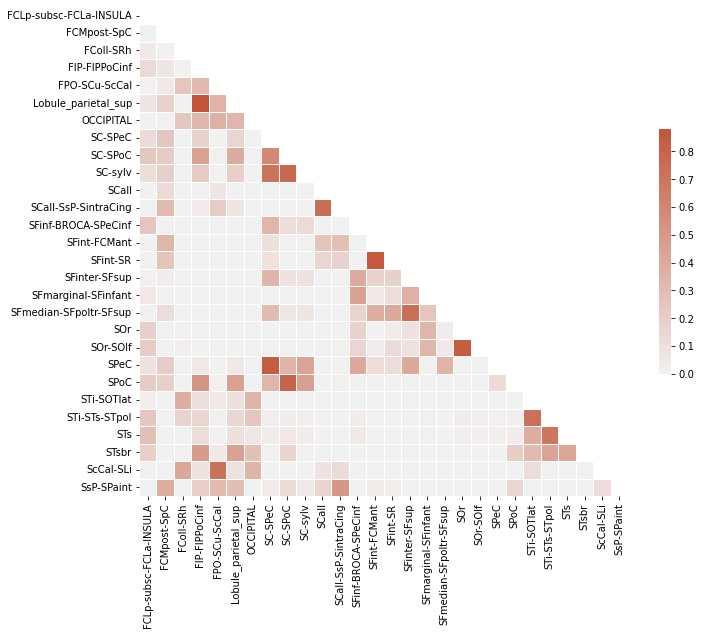

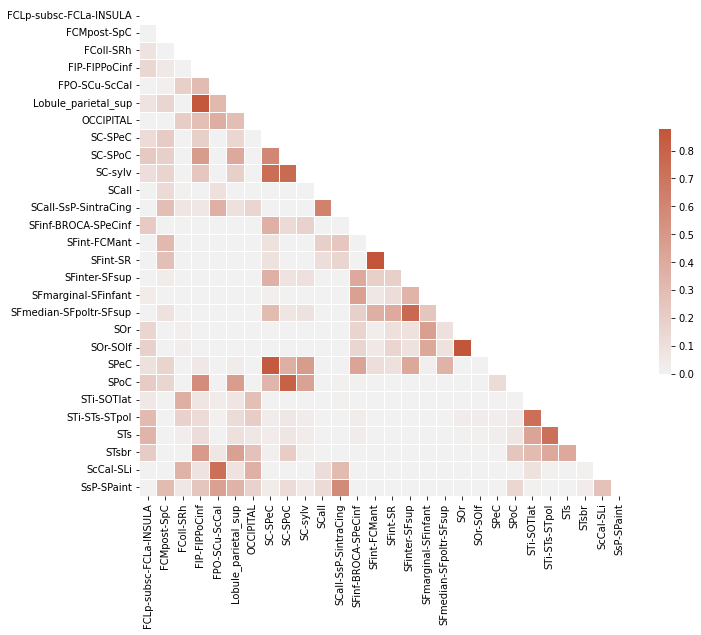

In [74]:
generate_corr_fig(right_dice_score)
generate_corr_fig(left_dice_score)

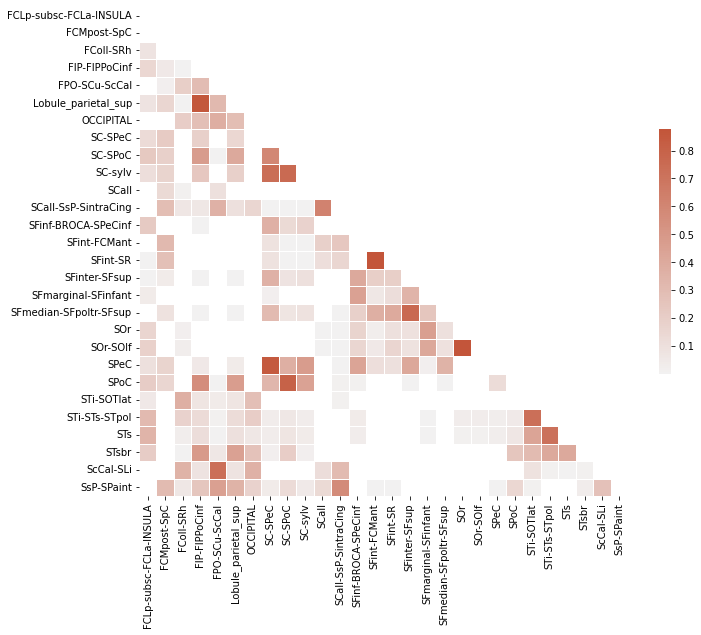

In [75]:
left_bin_dice_score = left_dice_score[left_dice_score > 0]
generate_corr_fig(left_bin_dice_score)

In [76]:
corr_matrix = pd.read_csv("/home/ad279118/tmp/corr_matrix.csv", index_col=0)
list_regions_left = [region for region in list_regions if region.endswith('_left')]
list_regions_left = sorted(list_regions_left)
list_regions_right = [region for region in list_regions if region.endswith('_right')]
list_regions_right = sorted(list_regions_right)
list_regions = list_regions_left + list_regions_right
corr_matrix = corr_matrix.reindex(index=list_regions, columns=list_regions)

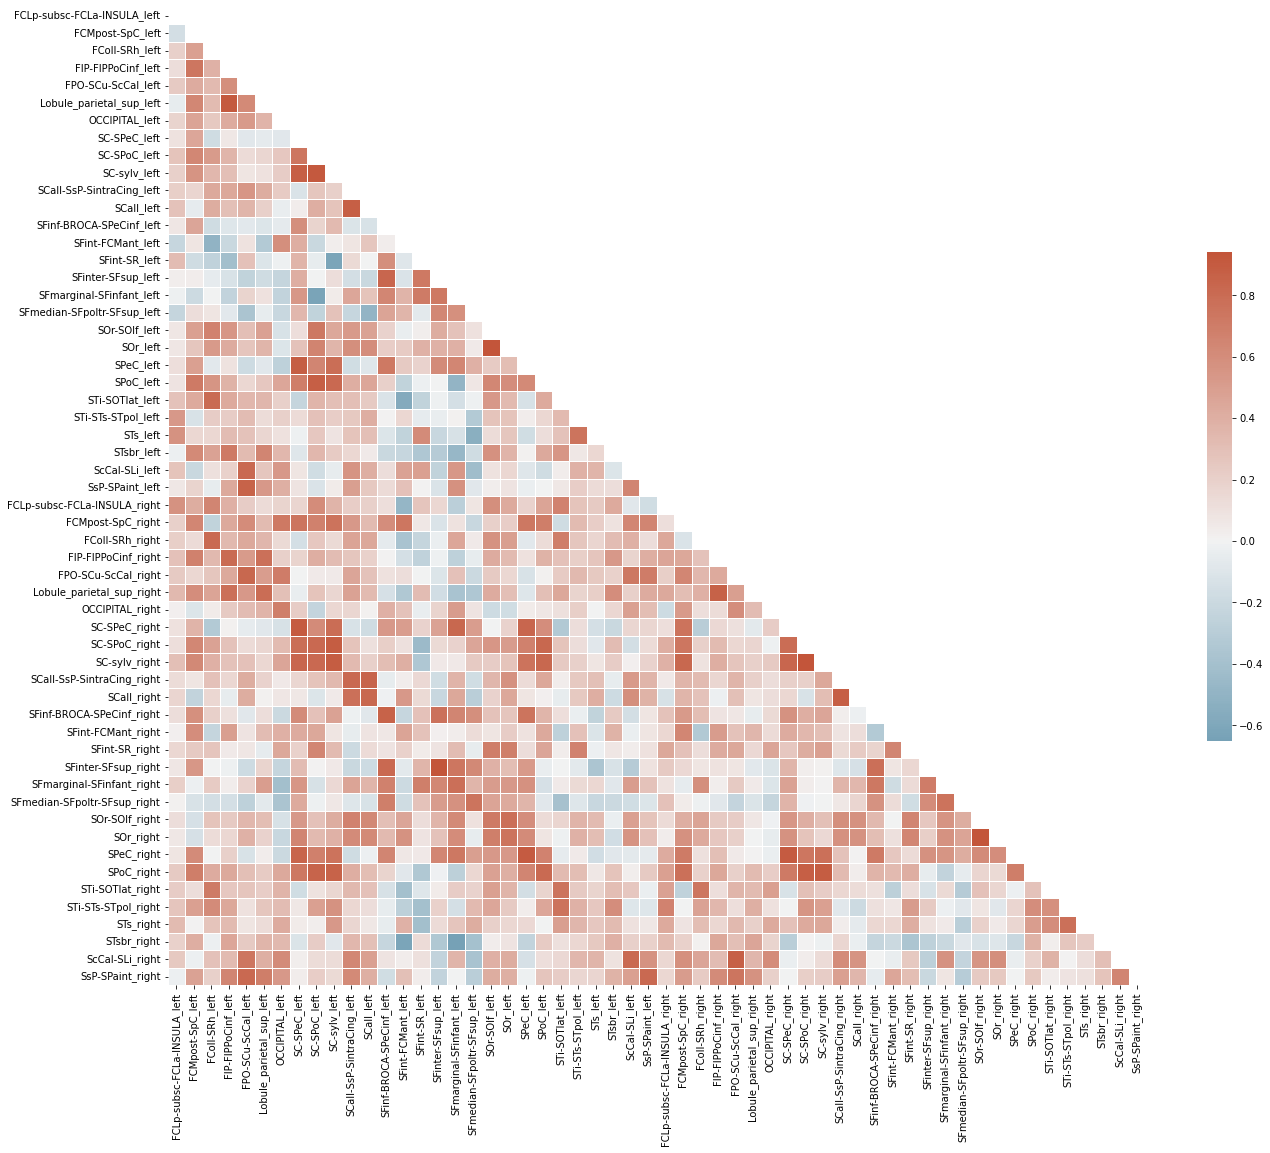

In [77]:
generate_corr_fig(corr_matrix, figsize=(22, 18))

In [78]:
dsc_matrix = pd.read_csv("/home/ad279118/tmp/dsc_matrix.csv", index_col=0)
list_regions_left = [region for region in list_regions if region.endswith('_left')]
list_regions_left = sorted(list_regions_left)
list_regions_right = [region for region in list_regions if region.endswith('_right')]
list_regions_right = sorted(list_regions_right)
list_regions = list_regions_left + list_regions_right
dsc_matrix = dsc_matrix.reindex(index=list_regions, columns=list_regions)

In [79]:
left_bin_mask =left_dice_score <= 0
right_bin_mask = right_dice_score <= 0

# Build combined mask
n_left = len(list_regions_left)
n_right = len(list_regions_right)

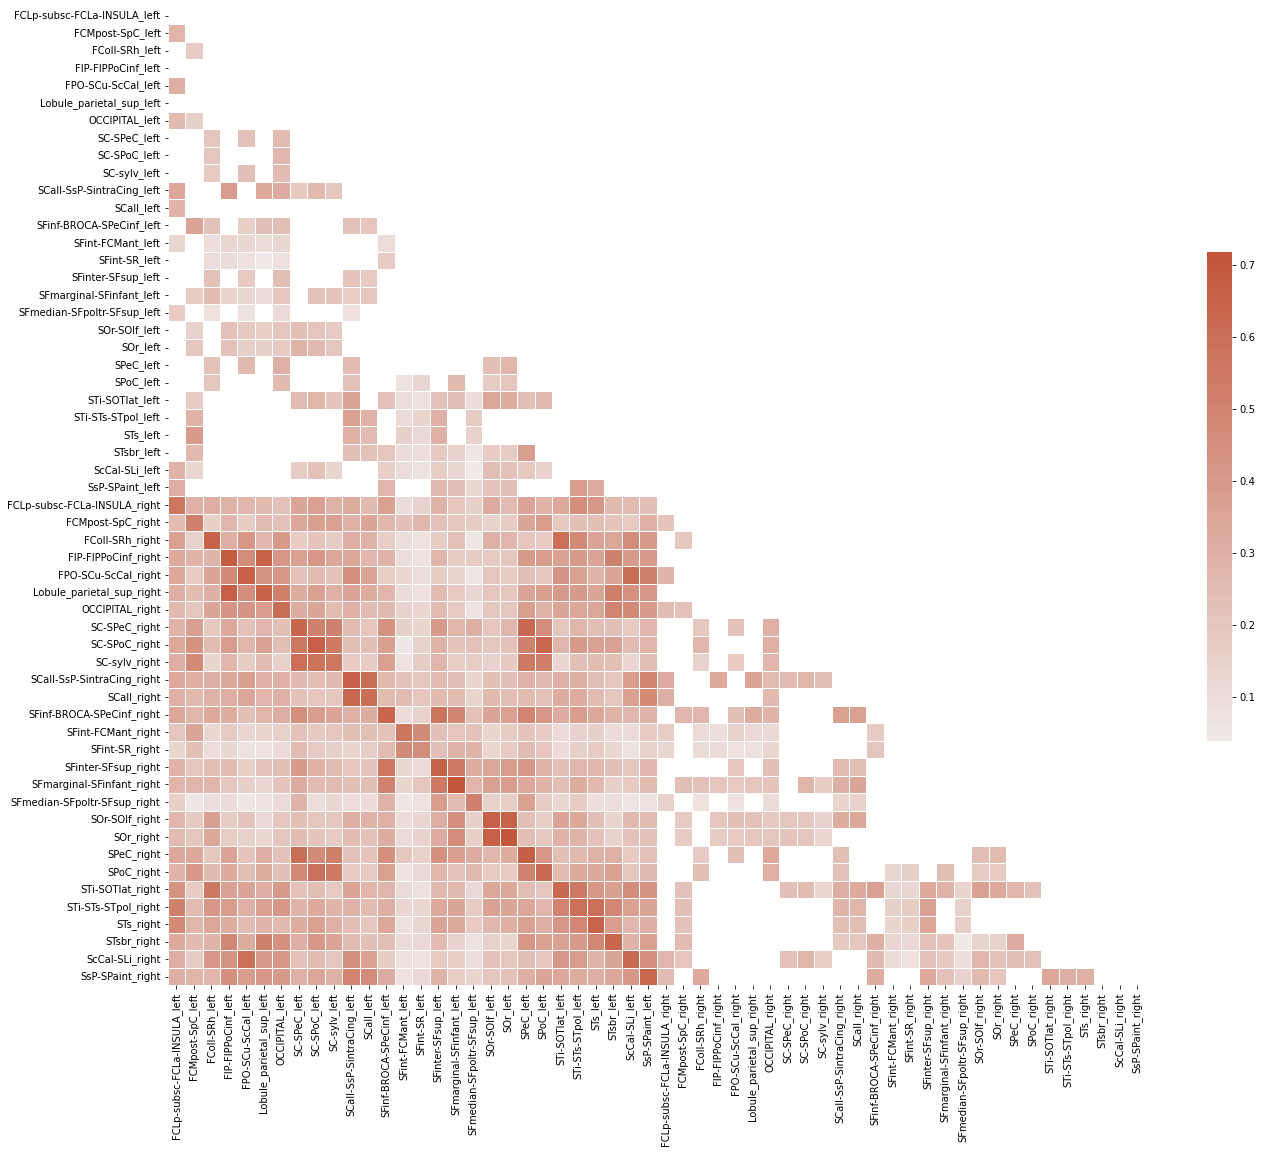

In [80]:
combined_mask = np.zeros_like(dsc_matrix, dtype=bool)
# 1 - Global upper-triangle masking
combined_mask |= np.triu(np.ones_like(dsc_matrix, dtype=bool))
# 2 - Inject the left hemisphere mask (top-left block)
combined_mask[:n_left, :n_left] |= ~left_bin_mask.values
# 3 - Inject the right hemisphere mask (bottom-right block)
combined_mask[n_right:, n_right:] |= ~right_bin_mask.values

generate_corr_fig(dsc_matrix, mask=combined_mask, figsize=(22, 18))

Text(0.5, 1.0, 'Comparison of genetic dice score between regions for both hemispheres')

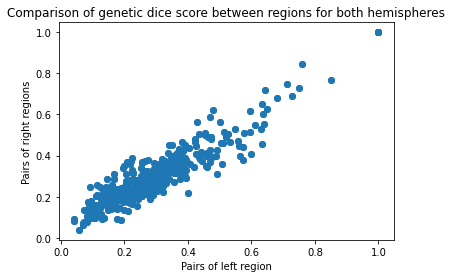

In [83]:
left_dice = dsc_matrix.reindex(index=list_regions_left, columns=list_regions_left)
right_dice = dsc_matrix.reindex(index=list_regions_right, columns=list_regions_right)

plt.scatter(left_dice.to_numpy().flatten(), right_dice.to_numpy().flatten())
plt.xlabel('Pairs of left region')
plt.ylabel('Pairs of right regions')
plt.title('Comparison of genetic dice score between regions for both hemispheres')

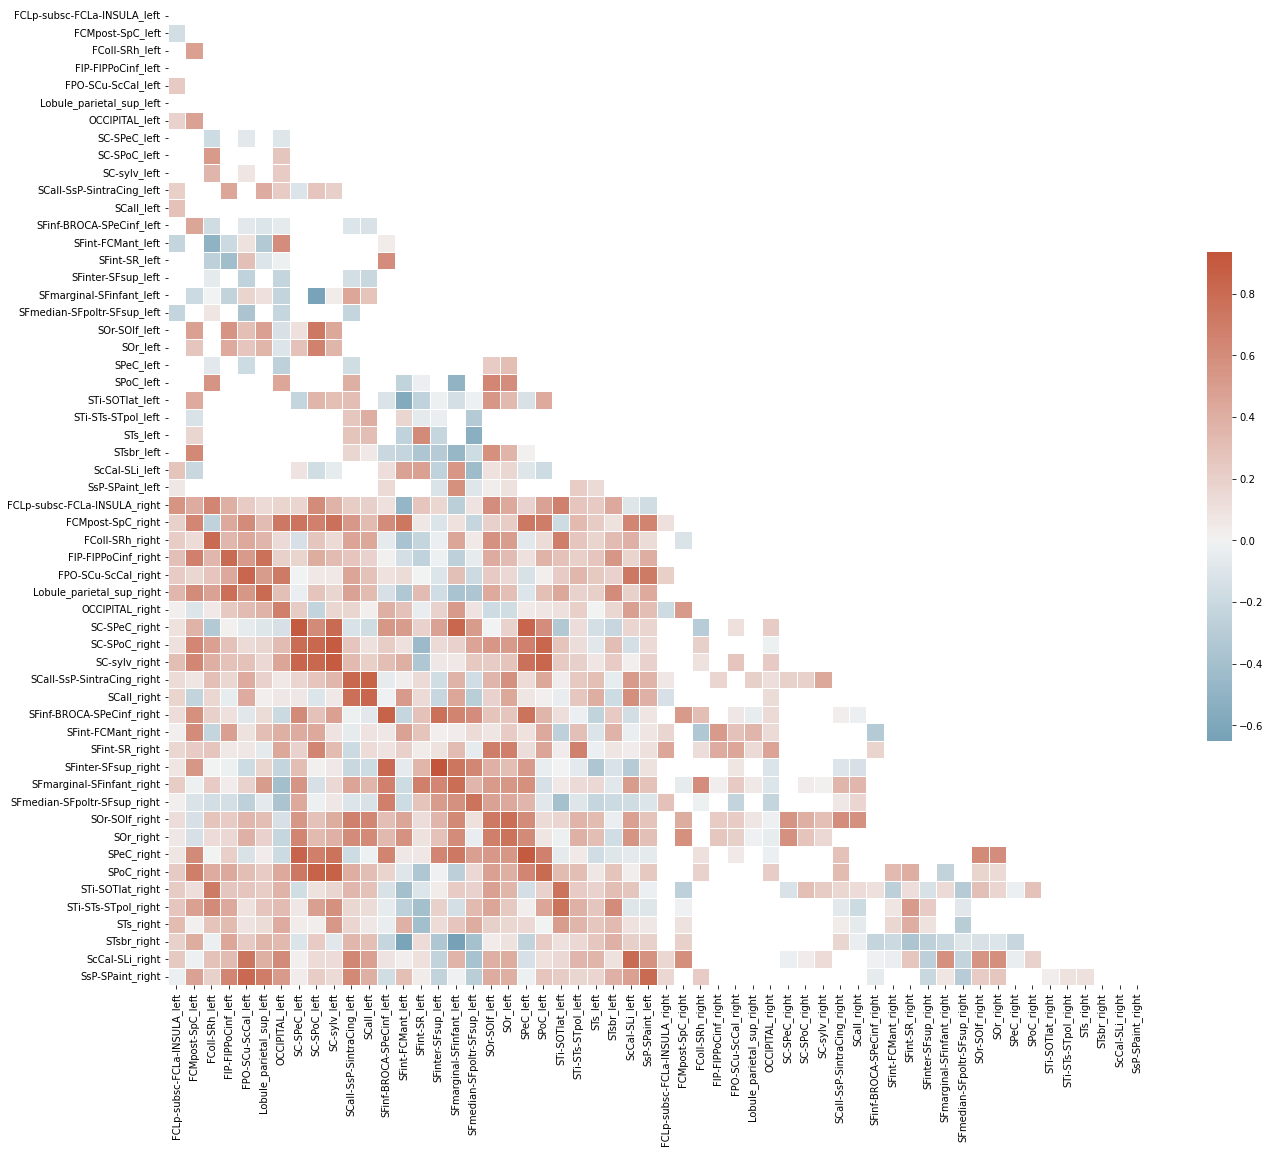

In [84]:
combined_mask = np.zeros_like(corr_matrix, dtype=bool)
# 1 - Global upper-triangle masking
combined_mask |= np.triu(np.ones_like(corr_matrix, dtype=bool))
# 2 - Inject the left hemisphere mask (top-left block)
combined_mask[:n_left, :n_left] |= ~left_bin_mask.values
# 3 - Inject the right hemisphere mask (bottom-right block)
combined_mask[n_left:, n_left:] |= ~right_bin_mask.values

generate_corr_fig(corr_matrix, mask=combined_mask, figsize=(22, 18))

In [85]:
left_gen_corr = corr_matrix.reindex(index=list_regions_left, columns=list_regions_left)
left_CKA = pd.read_csv("/neurospin/dico/data/deep_folding/current/models/Champollion_V1_after_ablation/analysis/CKA_matrix_left_dim32_subsNone_ukb40.csv", index_col=0)
left_CKA = left_CKA.reindex(index=regions, columns=regions)

right_gen_corr = corr_matrix.reindex(index=list_regions_right, columns=list_regions_right)
right_CKA = pd.read_csv("/neurospin/dico/data/deep_folding/current/models/Champollion_V1_after_ablation/analysis/CKA_matrix_right_dim32_subsNone_ukb40.csv", index_col=0)
right_CKA = right_CKA.reindex(index=regions, columns=regions)

left_CKA = left_CKA[left_bin_mask]
right_CKA = right_CKA[right_bin_mask]

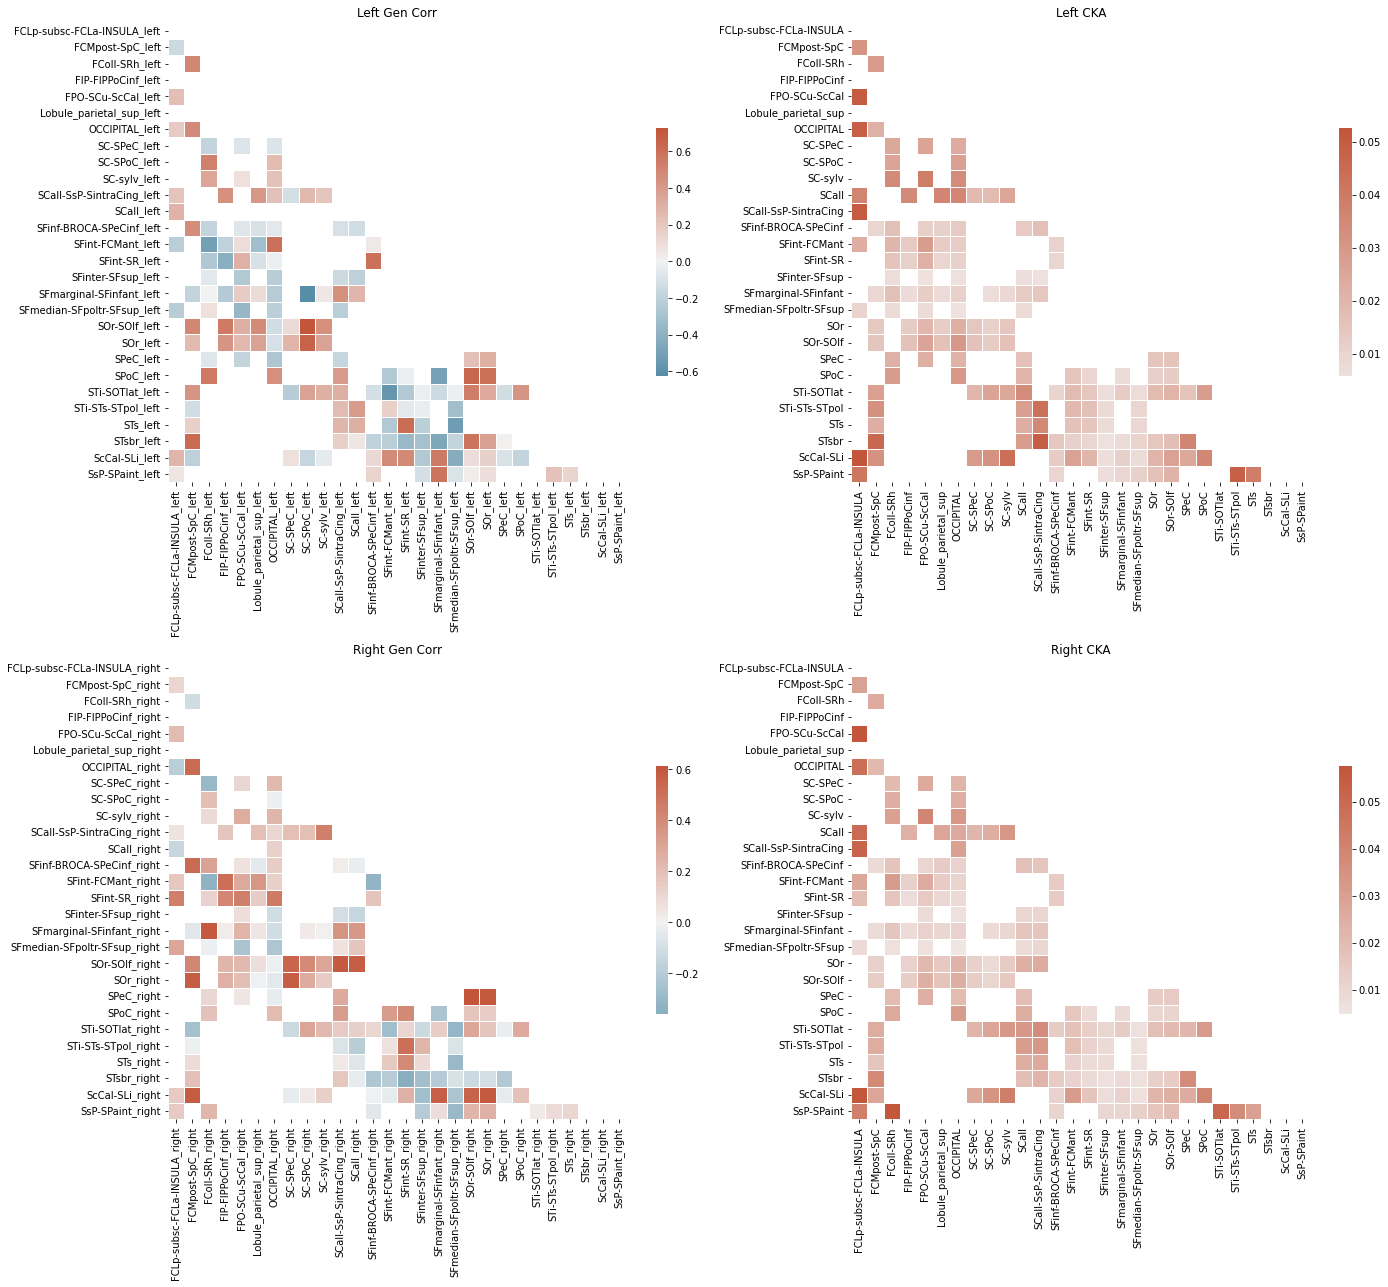

In [87]:
# Generate a mask for the upper triangle
left_mask_corr = np.triu(np.ones_like(left_gen_corr, dtype=bool))
right_mask_corr = np.triu(np.ones_like(right_gen_corr, dtype=bool))

left_mask_corr[:n_left, :n_left] |= ~left_bin_mask.values
right_mask_corr[:n_right:, :n_right] |= ~right_bin_mask.values

mask_cka = np.triu(np.ones_like(left_CKA, dtype=bool))

# Create a figure with two subplots side by side
fig, axes = plt.subplots(2, 2, figsize=(20, 18))

# Custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# --- First heatmap ---
sns.heatmap(left_gen_corr, mask=left_mask_corr, cmap=cmap, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, ax=axes[0,0])
axes[0,0].set_title("Left Gen Corr")

# --- Second heatmap ---
sns.heatmap(left_CKA, mask=mask_cka, cmap=cmap, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, ax=axes[0,1])
axes[0,1].set_title("Left CKA")

# --- Third heatmap ---
sns.heatmap(right_gen_corr, mask=right_mask_corr, cmap=cmap, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, ax=axes[1,0])
axes[1,0].set_title("Right Gen Corr")

# --- Forth heatmap ---
sns.heatmap(right_CKA, mask=mask_cka, cmap=cmap, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, ax=axes[1,1])
axes[1,1].set_title("Right CKA")

plt.tight_layout()
plt.show()


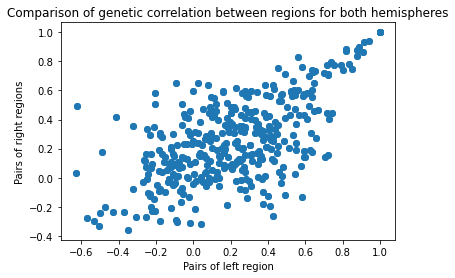

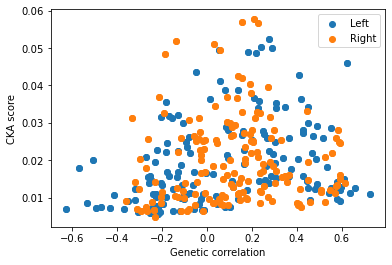

In [97]:
plt.scatter(left_gen_corr.to_numpy().flatten(), right_gen_corr.to_numpy().flatten())
plt.xlabel('Pairs of left region')
plt.ylabel('Pairs of right regions')
plt.title('Comparison of genetic correlation between regions for both hemispheres')
plt.show()
plt.scatter(left_gen_corr.to_numpy().flatten(),  left_CKA.to_numpy().flatten(), label='Left')
plt.scatter(right_gen_corr.to_numpy().flatten(),  right_CKA.to_numpy().flatten(), label='Right')
plt.xlabel('Genetic correlation')
plt.ylabel('CKA score')
plt.legend()
plt.show()

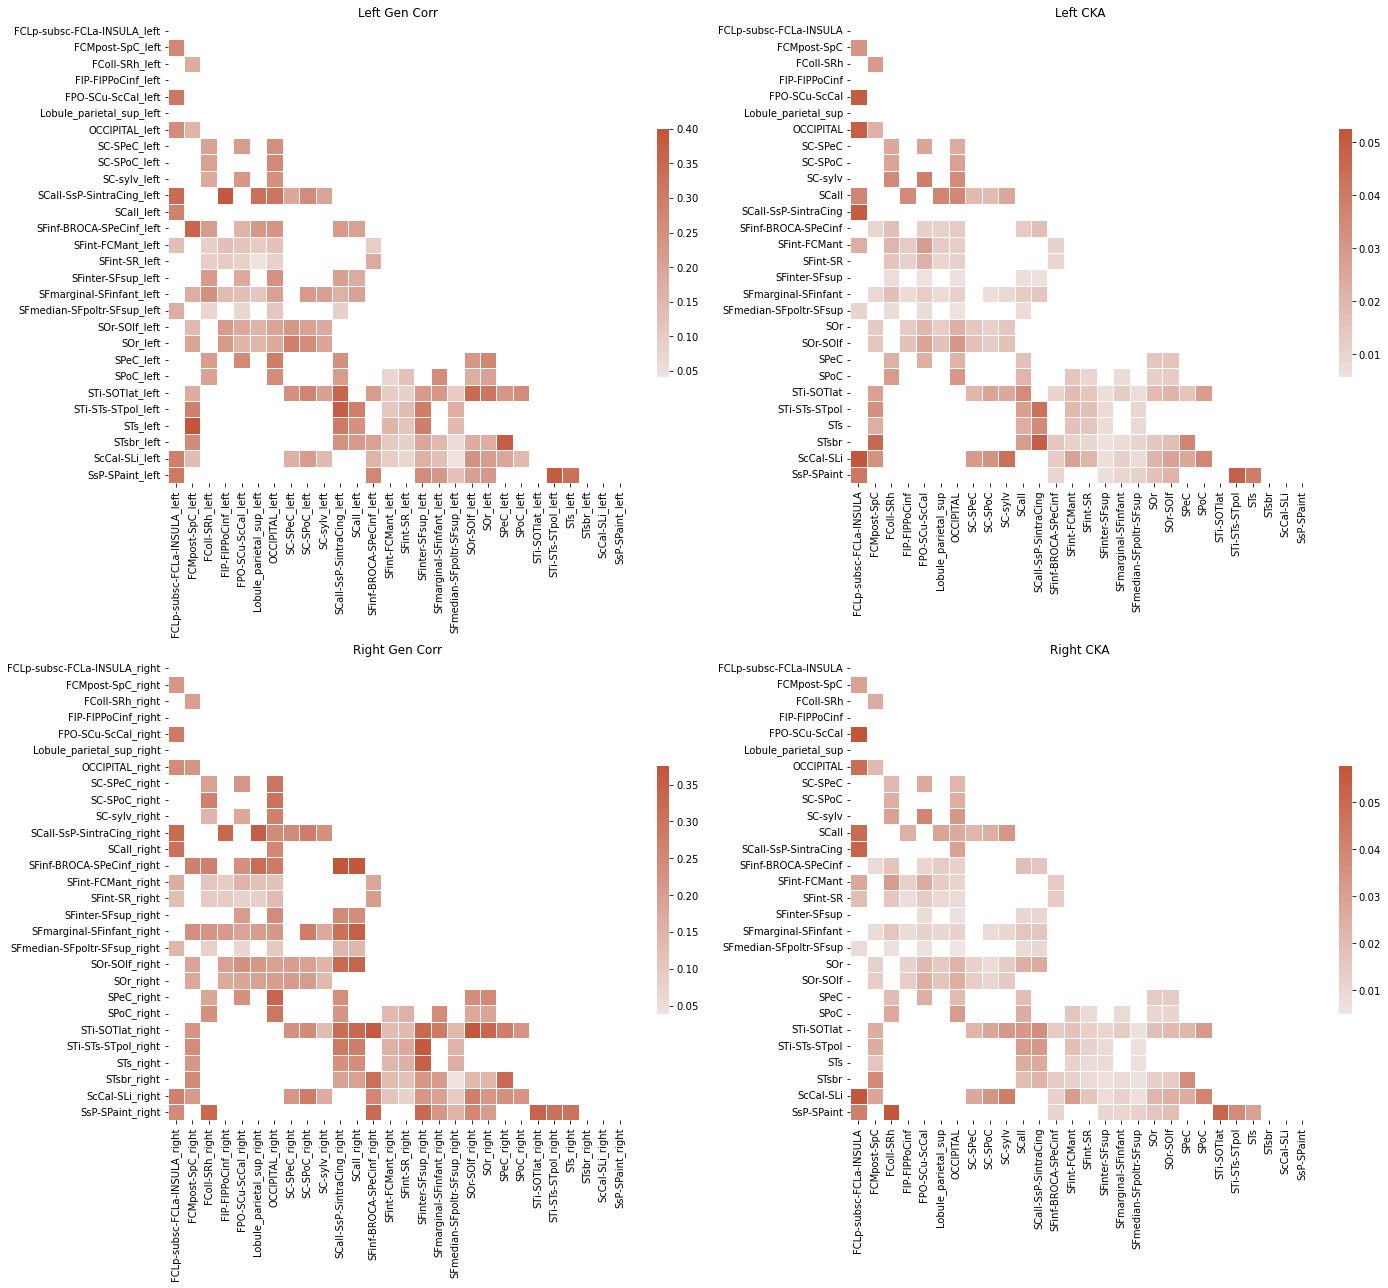

In [90]:
# Generate a mask for the upper triangle
left_mask_corr = np.triu(np.ones_like(left_dice, dtype=bool))
right_mask_corr = np.triu(np.ones_like(right_dice, dtype=bool))

left_mask_corr[:n_left, :n_left] |= ~left_bin_mask.values
right_mask_corr[:n_right:, :n_right] |= ~right_bin_mask.values

mask_cka = np.triu(np.ones_like(left_CKA, dtype=bool))

# Create a figure with two subplots side by side
fig, axes = plt.subplots(2, 2, figsize=(20, 18))

# Custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# --- First heatmap ---
sns.heatmap(left_dice, mask=left_mask_corr, cmap=cmap, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, ax=axes[0,0])
axes[0,0].set_title("Left Dice score")

# --- Second heatmap ---
sns.heatmap(left_CKA, mask=mask_cka, cmap=cmap, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, ax=axes[0,1])
axes[0,1].set_title("Left CKA")

# --- Third heatmap ---
sns.heatmap(right_dice, mask=right_mask_corr, cmap=cmap, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, ax=axes[1,0])
axes[1,0].set_title("Right Dice score")

# --- Forth heatmap ---
sns.heatmap(right_CKA, mask=mask_cka, cmap=cmap, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5}, ax=axes[1,1])
axes[1,1].set_title("Right CKA")

plt.tight_layout()
plt.show()


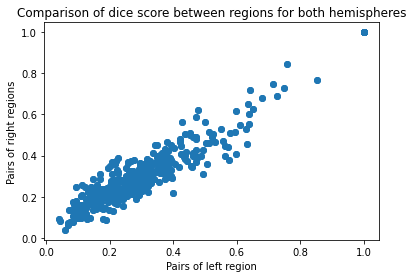

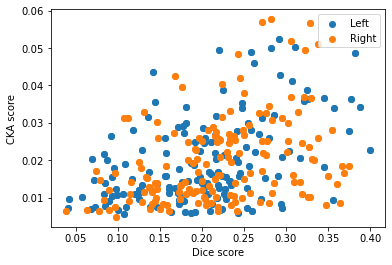

In [98]:
plt.scatter(left_dice.to_numpy().flatten(), right_dice.to_numpy().flatten())
plt.xlabel('Pairs of left region')
plt.ylabel('Pairs of right regions')
plt.title('Comparison of dice score between regions for both hemispheres')
plt.show()
plt.scatter(left_dice.to_numpy().flatten(),  left_CKA.to_numpy().flatten(), label='Left')
plt.scatter(right_dice.to_numpy().flatten(),  right_CKA.to_numpy().flatten(), label='Right')
plt.xlabel('Dice score')
plt.ylabel('CKA score')
plt.legend()
plt.show()

In [ ]:
# For each row, sort correlations descending and take the top 2 non-self correlations
top3 = corr_matrix.apply(
    lambda row: row.drop(row.name).sort_values(ascending=False).head(3).index.tolist(),
    axis=1
)

top3

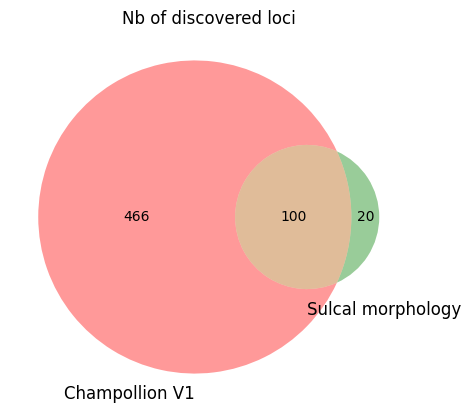

In [10]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Use the venn2 function
plt.title('Nb of discovered loci')
venn2(subsets = (466, 20, 100), set_labels = ('Champollion V1', 'Sulcal morphology'))
plt.show()